In [10]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from plotly.offline import init_notebook_mode

# Initialize plotly for notebook
init_notebook_mode(connected=True)

# Check versions
print("NumPy version:", np.__version__)
print("Pandas version:", pd.__version__)
print("Matplotlib version:", plt.matplotlib.__version__)
print("Seaborn version:", sns.__version__)

print("\n Libraries imported successfully!")

NumPy version: 2.3.5
Pandas version: 2.3.3
Matplotlib version: 3.10.6
Seaborn version: 0.13.2

 Libraries imported successfully!


In [8]:
# Load the CSV file
df = pd.read_csv('cs_students.csv')

# Display the dataframe
print("Dataset loaded successfully!")
print("\nFirst 5 rows:")
df.head()

Dataset loaded successfully!

First 5 rows:


,Student ID,Name,Gender,Age,GPA,Major,Interested Domain,Projects,Future Career,Python,SQL,Java
0,1,John Smith,Male,21,3.5,Computer Science,Artificial Intelligence,Chatbot Development,Machine Learning Researcher,Strong,Strong,Weak
1,2,Alice Johnson,Female,20,3.2,Computer Science,Data Science,Data Analytics,Data Scientist,Average,Strong,Weak
2,3,Robert Davis,Male,22,3.8,Computer Science,Software Development,E-commerce Website,Software Engineer,Strong,Strong,Average
3,4,Emily Wilson,Female,21,3.7,Computer Science,Web Development,Full-Stack Web App,Web Developer,Weak,Strong,Strong
4,5,Michael Brown,Male,23,3.4,Computer Science,Cybersecurity,Network Security,Information Security Analyst,Average,Weak,Strong


In [7]:
# Check data types of all variables
print("Data types of variables:")
print(df.dtypes)

print("\n" + "="*50 + "\n")

# More detailed info
print("Dataset info:")
df.info()

Data types of variables:
Student ID             int64
Name                  object
Gender                object
Age                    int64
GPA                  float64
Major                 object
Interested Domain     object
Projects              object
Future Career         object
Python                object
SQL                   object
Java                  object
dtype: object


Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Student ID         180 non-null    int64  
 1   Name               180 non-null    object 
 2   Gender             180 non-null    object 
 3   Age                180 non-null    int64  
 4   GPA                180 non-null    float64
 5   Major              180 non-null    object 
 6   Interested Domain  180 non-null    object 
 7   Projects           180 non-null    object 
 8   Future 

In [6]:
# Display basic statistics
print("Basic Statistics:")
print(df.describe(include='all'))

print("\n" + "="*50 + "\n")

# Check for missing values
print("Missing values:")
print(df.isnull().sum())

print("\n" + "="*50 + "\n")

# Check dataset shape
print(f"Dataset shape: {df.shape} (rows, columns)")
print(f"Number of students: {len(df)}")
print(f"Number of columns: {len(df.columns)}")

Basic Statistics:
        Student ID          Name Gender         Age         GPA  \
count   180.000000           180    180  180.000000  180.000000   
unique         NaN            89      2         NaN         NaN   
top            NaN  James Wilson   Male         NaN         NaN   
freq           NaN             8    102         NaN         NaN   
mean     90.500000           NaN    NaN   22.116667    3.615000   
std      52.105662           NaN    NaN    2.823040    0.177341   
min       1.000000           NaN    NaN   20.000000    3.200000   
25%      45.750000           NaN    NaN   21.000000    3.500000   
50%      90.500000           NaN    NaN   22.000000    3.600000   
75%     135.250000           NaN    NaN   22.250000    3.700000   
max     180.000000           NaN    NaN   37.000000    3.900000   

                   Major        Interested Domain  \
count                180                      180   
unique                 1                       27   
top     Computer S

In [19]:
# Convert columns to numpy arrays
gpa_array = df['GPA'].values
age_array = df['Age'].values

# NumPy statistical operations
print("NumPy Statistical Analysis:")
print(f"Mean GPA: {np.mean(gpa_array):.2f}")
print(f"Median GPA: {np.median(gpa_array):.2f}")
print(f"Standard Deviation GPA: {np.std(gpa_array):.2f}")
print(f"Min GPA: {np.min(gpa_array):.2f}")
print(f"Max GPA: {np.max(gpa_array):.2f}")
print(f"GPA Range: {np.ptp(gpa_array):.2f}")

print("\nAge Statistics:")
print(f"Mean Age: {np.mean(age_array):.2f}")
print(f"Unique Ages: {np.unique(age_array)}")
print(f"Age Distribution: {np.bincount(age_array)}")

NumPy Statistical Analysis:
Mean GPA: 3.62
Median GPA: 3.60
Standard Deviation GPA: 0.18
Min GPA: 3.20
Max GPA: 3.90
GPA Range: 0.70

Age Statistics:
Mean Age: 22.12
Unique Ages: [20 21 22 23 29 31 33 35 37]
Age Distribution: [ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 34 48 53 36
  0  0  0  0  0  2  0  1  0  2  0  2  0  2]


In [18]:
# Convert text skill levels to numbers so we can use them in calculations
# Weak = 1, Average = 2, Strong = 3
skill_map = {'Weak': 1, 'Average': 2, 'Strong': 3}
df['Python_num'] = df['Python'].map(skill_map)
df['SQL_num'] = df['SQL'].map(skill_map)
df['Java_num'] = df['Java'].map(skill_map)

print("Data prepared for plotting!")

Data prepared for plotting!


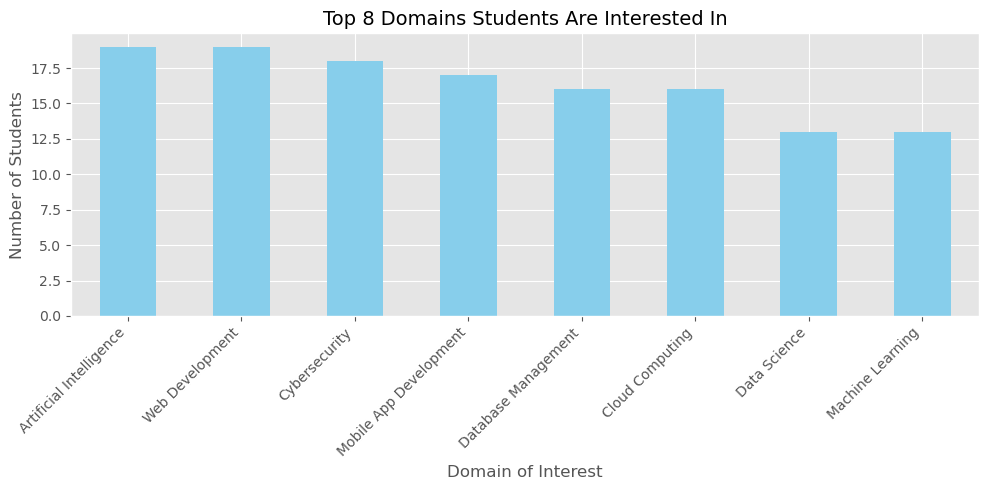

In [17]:
# Create a bar chart to see which domains are most popular among students
plt.figure(figsize=(10, 5))  # Set the figure size (width, height)

# Get the count of students for each domain and take the top 8
top_domains = df['Interested Domain'].value_counts().head(8)

# Create the bar chart
top_domains.plot(kind='bar', color='skyblue')

# Add title and labels
plt.title('Top 8 Domains Students Are Interested In', fontsize=14)
plt.xlabel('Domain of Interest', fontsize=12)
plt.ylabel('Number of Students', fontsize=12)

# Rotate x-axis labels so they don't overlap
plt.xticks(rotation=45, ha='right')

# Adjust layout to prevent clipping
plt.tight_layout()

# Display the chart
plt.show()

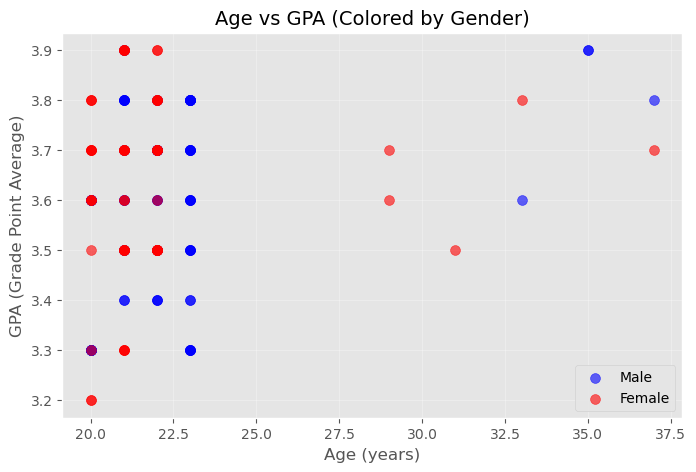

In [15]:
# Create a scatter plot to see if there's a relationship between age and GPA
plt.figure(figsize=(8, 5))

# Define colors for each gender
colors = {'Male': 'blue', 'Female': 'red'}

# Plot each gender separately so we can color them differently
for gender in ['Male', 'Female']:
    # Get only rows for this gender
    subset = df[df['Gender'] == gender]
    
    # Create scatter plot for this gender
    plt.scatter(
        subset['Age'],           # x-axis: Age
        subset['GPA'],           # y-axis: GPA
        c=colors[gender],        # color for this gender
        label=gender,            # label for legend
        alpha=0.6,               # transparency (0=invisible, 1=solid)
        s=50                     # size of points
    )

# Add title and labels
plt.title('Age vs GPA (Colored by Gender)', fontsize=14)
plt.xlabel('Age (years)', fontsize=12)
plt.ylabel('GPA (Grade Point Average)', fontsize=12)

# Add legend to show which color represents which gender
plt.legend()

# Add grid for better readability
plt.grid(True, alpha=0.3)

# Display the chart
plt.show()

# Interpretation:
# - Each point represents one student
# - Blue points = Male students, Red points = Female students
# - Look for patterns: Do older students have higher GPAs?
# - Are there any outliers (students with very high or low GPA)?

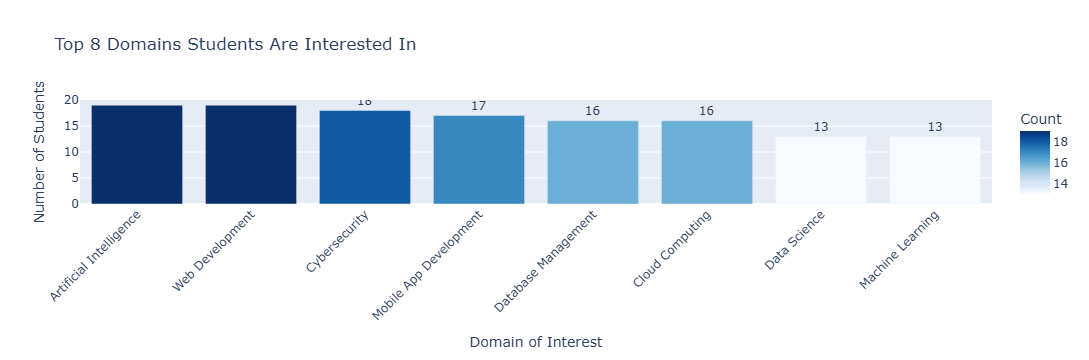

In [13]:
# Prepare the data: count students per domain and take top 8
domain_counts = df['Interested Domain'].value_counts().head(8).reset_index()
domain_counts.columns = ['Domain', 'Count']

# Create an interactive bar chart
fig = px.bar(
    domain_counts, 
    x='Domain', 
    y='Count', 
    title='Top 8 Domains Students Are Interested In',
    color='Count',  # Color bars by count value
    color_continuous_scale='Blues',  # Use blue color scale
    text='Count'  # Display count on top of bars
)

# Customize the layout
fig.update_traces(textposition='outside')  # Place text above bars
fig.update_layout(
    xaxis_title='Domain of Interest',
    yaxis_title='Number of Students',
    xaxis_tickangle=-45  # Rotate x-axis labels
)

# Display the interactive chart (you can hover over bars)
fig.show()

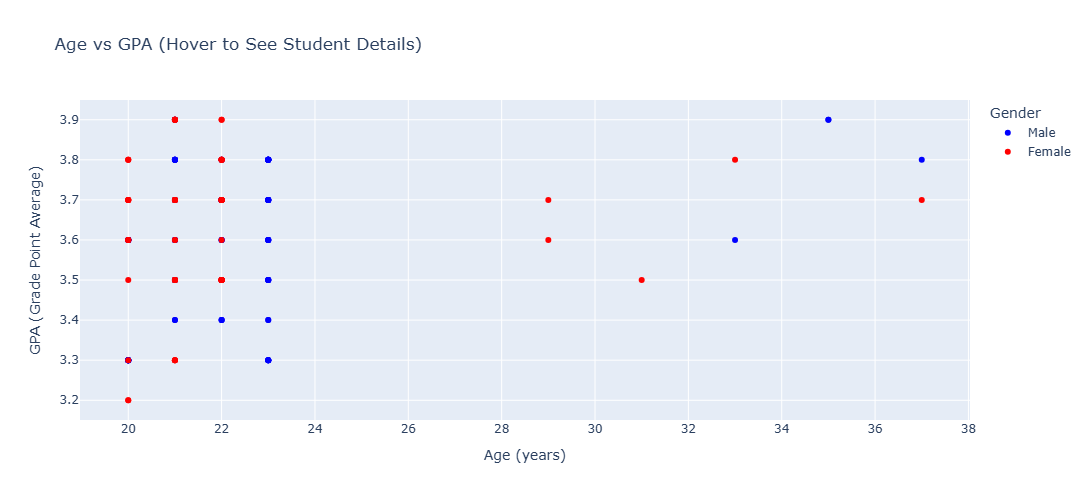

In [12]:
# Create an interactive scatter plot
fig = px.scatter(
    df, 
    x='Age', 
    y='GPA', 
    color='Gender',  # Color points by gender
    title='Age vs GPA (Hover to See Student Details)',
    color_discrete_map={'Male': 'blue', 'Female': 'red'},  # Set specific colors
    hover_data=['Name', 'Interested Domain', 'Future Career']  # Show these on hover
)

# Customize the layout
fig.update_layout(
    xaxis_title='Age (years)',
    yaxis_title='GPA (Grade Point Average)',
    height=500
)

# Display the interactive chart
# Try hovering over points to see student details!
fig.show()

# Interactive features:
# - Hover over points to see student name, domain, and career
# - Click on legend items to show/hide genders
# - Zoom in/out using scroll wheel
# - Pan by clicking and dragging